In [151]:
%pip install tensorflow

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [152]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [153]:
%pip install numpy pandas nltk rouge-score matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [154]:
%pip install googletrans==4.0.0-rc1

Note: you may need to restart the kernel to use updated packages.Requirement already satisfied: googletrans==4.0.0-rc1 in e:\software\python\lib\site-packages (4.0.0rc1)




[notice] A new release of pip available: 22.3.1 -> 24.3.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [155]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Input, Embedding, Dense, LSTM, Dropout
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
from sklearn.model_selection import train_test_split
import random
from nltk.corpus import wordnet
from googletrans import Translator

In [156]:
# Memuat dataset
df = pd.read_csv('liputan6.csv')
df = df[['clean_article', 'clean_summary']]

# Menampilkan contoh data
print(df.head())

                                       clean_article  \
0  Liputan6. com, Surabaya : Radiogram Direktorat...   
1  Liputan6. com, Jakarta : Berbeda dengan aliran...   
2  Liputan6. com, Jambi : Ratusan orang dari Kesa...   
3  Liputan6. com, Jakarta : Badan Penyehatan Perb...   
4  Liputan6. com, Jakarta : Ketua Komisi I DPR Ya...   

                                       clean_summary  
0  Gubernur Jatim Imam Utomo tak mau melantik Bup...  
1  Pelukis RM Koestarto memamerkan hasil karyanya...  
2  Dua kelompok pengunjuk rasa di Jambi, menuntut...  
3  BPPN masih mengkaji bank rekap yang dianggap p...  
4  Kendati Dewan Papua membatalkan deklarasi keme...  


In [157]:
# Menampilkan jumlah total data dalam dataset
print("Total data dalam dataset:", len(df))

# Menampilkan jumlah data yang ada di setiap kolom 'clean_article' dan 'clean_summary'
print("Total data di kolom 'clean_article':", df['clean_article'].notnull().sum())
print("Total data di kolom 'clean_summary':", df['clean_summary'].notnull().sum())

# Menjumlahkan total data non-null dari kedua kolom
total_non_null = df['clean_article'].notnull().sum() + df['clean_summary'].notnull().sum()
print("Total dari kedua kolom (clean_article dan clean_summary):", total_non_null)

# Menampilkan informasi jumlah kolom dan jenis data
print("\nInfo Dataset:")
df.info()

Total data dalam dataset: 10972
Total data di kolom 'clean_article': 10972
Total data di kolom 'clean_summary': 10972
Total dari kedua kolom (clean_article dan clean_summary): 21944

Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10972 entries, 0 to 10971
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   clean_article  10972 non-null  object
 1   clean_summary  10972 non-null  object
dtypes: object(2)
memory usage: 171.6+ KB


In [158]:
# Mengambil subset data
df = df.sample(frac=0.10, random_state=50)  # Menggunakan 10% dari dataset

In [159]:
# Menampilkan jumlah total data dalam dataset
print("Total data dalam dataset:", len(df))

# Menampilkan jumlah data yang ada di setiap kolom 'clean_article' dan 'clean_summary'
print("Total data di kolom 'clean_article':", df['clean_article'].notnull().sum())
print("Total data di kolom 'clean_summary':", df['clean_summary'].notnull().sum())

# Menjumlahkan total data non-null dari kedua kolom
total_non_null = df['clean_article'].notnull().sum() + df['clean_summary'].notnull().sum()
print("Total dari kedua kolom (clean_article dan clean_summary):", total_non_null)

Total data dalam dataset: 1097
Total data di kolom 'clean_article': 1097
Total data di kolom 'clean_summary': 1097
Total dari kedua kolom (clean_article dan clean_summary): 2194


In [160]:
# Menggunakan Tokenizer untuk teks
tokenizer = Tokenizer()
tokenizer.fit_on_texts(df['clean_article'].tolist() + df['clean_summary'].tolist())

# Konversi teks menjadi sequences
input_sequences = tokenizer.texts_to_sequences(df['clean_article'].tolist())
target_sequences = tokenizer.texts_to_sequences(df['clean_summary'].tolist())

# Padding sequences untuk memastikan panjangnya seragam
max_input_len = 500  # Batasi panjang maksimum input sequence
max_target_len = 50  # Batasi panjang maksimum target sequence

input_sequences = pad_sequences(input_sequences, maxlen=max_input_len, padding='post')
target_sequences = pad_sequences(target_sequences, maxlen=max_target_len, padding='post')

# Mendapatkan ukuran vocabulary
vocab_size = len(tokenizer.word_index) + 1

# Periksa panjang input dan target sequences yang sudah diproses
print("Panjang input sequences:", max_input_len)
print("Panjang target sequences:", max_target_len)

Panjang input sequences: 500
Panjang target sequences: 50


In [161]:
# Fungsi untuk augmentasi teks dengan mengganti kata dengan sinonim
def synonym_replacement(text):
    words = text.split()
    new_words = words.copy()
    word_idx = random.randint(0, len(words)-1)  # Pilih indeks acak
    word = words[word_idx]
    
    # Mendapatkan sinonim
    synonyms = wordnet.synsets(word)
    if synonyms:
        synonym = random.choice(synonyms).lemmas()[0].name()
        new_words[word_idx] = synonym if synonym != word else word  # Pastikan tidak mengganti dengan kata yang sama
    
    return ' '.join(new_words)

# Fungsi back translation (terjemahkan ke bahasa Inggris, kemudian kembali ke bahasa Indonesia)
def back_translation(text, src='id', dest='en'):
    translator = Translator()
    translated = translator.translate(text, src=src, dest=dest).text
    back_translated = translator.translate(translated, src=dest, dest=src).text
    return back_translated

# Fungsi untuk augmentasi dataset
def augment_dataset(df):
    augmented_articles = []
    augmented_summaries = []
    
    for i in range(len(df)):
        article = df.iloc[i]['clean_article']
        summary = df.iloc[i]['clean_summary']
        
        # Menerapkan augmentasi
        augmented_articles.append(synonym_replacement(article))
        augmented_summaries.append(synonym_replacement(summary))
    
    augmented_df = pd.DataFrame({
        'clean_article': augmented_articles,
        'clean_summary': augmented_summaries
    })
    
    return augmented_df

In [162]:
# Model dengan validasi
X_train, X_val, y_train, y_val = train_test_split(input_sequences, target_sequences, test_size=0.2, random_state=42)

# Menggunakan `max_input_len` untuk padding target sequences
y_train = pad_sequences(y_train, maxlen=max_input_len, padding='post')
y_val = pad_sequences(y_val, maxlen=max_input_len, padding='post')

# Model
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=256, input_length=max_input_len))  # Dimensi embedding lebih besar
model.add(LSTM(256, return_sequences=True))  # LSTM dengan lebih banyak unit
model.add(Dropout(0.4))  # Dropout lebih tinggi untuk mengurangi overfitting
model.add(LSTM(256, return_sequences=True))  # Layer LSTM kedua
model.add(Dropout(0.4))  # Dropout tambahan
model.add(Dense(vocab_size, activation='softmax'))  # Output layer yang lebih padat
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])  # Gunakan Adam optimizer

# Memastikan model dibangun dengan benar sebelum melihat summary
model.build(input_shape=(None, max_input_len))  # Memaksa model untuk dibangun dengan input shape yang benar
model.summary()  # Menampilkan summary model

e:\Software\Python\lib\site-packages\keras\src\layers\core\embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_11 (Embedding)        │ (None, 500, 256)       │     3,945,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_18 (LSTM)                  │ (None, 500, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_19 (LSTM)                  │ (None, 500, 256)       │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 500, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 500, 15411)     │     3,960,627 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,956,467 (34.17 MB)

 Trainable params: 8,956,467 (34.17 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks untuk training
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Melatih model
history = model.fit(X_train, y_train, epochs=50, batch_size=128, validation_data=(X_val, y_val),
                    callbacks=[lr_scheduler, early_stopping])

Epoch 1/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 259s 36s/step - accuracy: 0.6276 - loss: 9.1486 - val_accuracy: 0.9558 - val_loss: 6.3877 - learning_rate: 0.0010
Epoch 2/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 271s 39s/step - accuracy: 0.9556 - loss: 5.4123 - val_accuracy: 0.9558 - val_loss: 2.4309 - learning_rate: 0.0010
Epoch 3/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 256s 37s/step - accuracy: 0.9555 - loss: 1.8396 - val_accuracy: 0.9558 - val_loss: 0.6323 - learning_rate: 0.0010
Epoch 4/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 253s 37s/step - accuracy: 0.9559 - loss: 0.6051 - val_accuracy: 0.9558 - val_loss: 0.5440 - learning_rate: 0.0010
Epoch 5/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 251s 37s/step - accuracy: 0.9558 - loss: 0.5467 - val_accuracy: 0.9558 - val_loss: 0.5418 - learning_rate: 0.0010
Epoch 6/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 260s 38s/step - accuracy: 0.9558 - loss: 0.5317 - val_accuracy: 0.9550 - val_loss: 0.5196 - learning_rate: 0.0010
Epoch 7/50
7/7 ━━━━━━━━━━━━━━━━━━━━ 255s 37s/step - accuracy: 0.9552 - loss: 0.5143 - val_accuracy: 

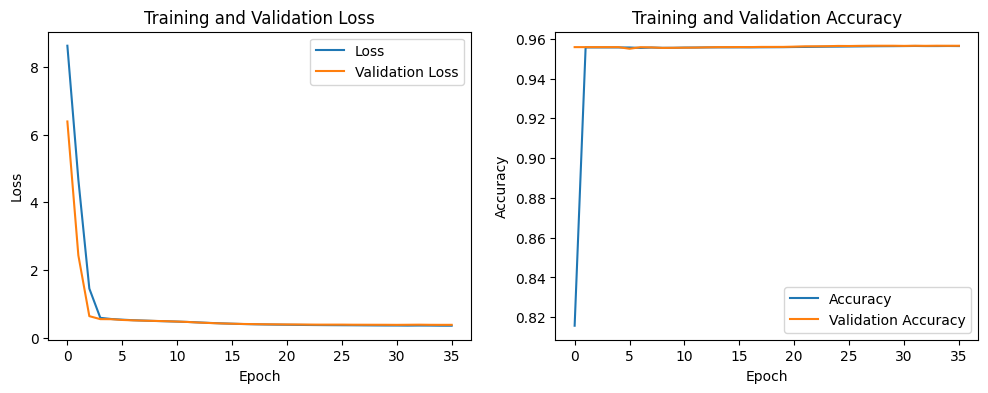

In [164]:
# Plotting Loss dan Accuracy
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [165]:
# Fungsi untuk merangkum teks
def summarize_text(input_text, tokenizer, model, max_input_len=500, max_target_len=50):
    # Mengonversi teks input menjadi sequence menggunakan tokenizer
    input_sequence = tokenizer.texts_to_sequences([input_text])
    
    # Padding sequence agar panjangnya sesuai dengan max_input_len
    input_sequence = pad_sequences(input_sequence, maxlen=max_input_len, padding='post')
    
    # Melakukan prediksi untuk teks input
    prediction = model.predict(input_sequence)
    
    # Mengambil indeks yang paling mungkin pada setiap waktu
    predicted_sequence = np.argmax(prediction, axis=-1)[0]
    
    # Mengonversi kembali indeks ke kata-kata
    reverse_word_map = {index: word for word, index in tokenizer.word_index.items()}
    predicted_words = [reverse_word_map.get(index, '') for index in predicted_sequence]
    
    # Mengembalikan hasil sebagai teks yang digabungkan
    return ' '.join(predicted_words).strip()

# Mengambil input teks dari pengguna
input_text = input("Masukkan artikel yang ingin diringkas: ")

# Uji model dengan input teks dinamis
summary = summarize_text(input_text, tokenizer, model)
print("Ringkasan:", summary)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Ringkasan: pemerintah di di di
